In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

In [2]:
def compile_metal_data(df, year, geography, variables_to_keep):
    df = df.copy()

    # Handle REF_DATE flexibly
    def parse_date(date_str):
        try:
            return pd.to_datetime(date_str, format="%Y-%m")
        except:
            try:
                return pd.to_datetime(date_str, format="%Y")
            except:
                return pd.NaT

    df['REF_DATE'] = df['REF_DATE'].apply(parse_date)
    df = df.dropna(subset=['REF_DATE'])  # Drop rows with unparsable dates

    # Filter for year, geography, and selected variables
    df_filtered = df[
        (df['REF_DATE'].dt.year == year) &
        (df['GEO'] == geography) &
        (df['Variables'].isin(variables_to_keep))
    ]

    # Remove units from product names (anything inside parentheses)
    df_filtered['Product_clean'] = df_filtered['Products'].apply(lambda x: re.sub(r'\s*\([^)]*\)', '', x).strip())

    # Split into Commodity and Product_type
    def split_product(product_name):
        if ',' in product_name:
            parts = product_name.split(',', 1)
            commodity = parts[0].strip()
            product_type = parts[1].strip()
        else:
            commodity = product_name.strip()
            product_type = 'undefined'
        return pd.Series([commodity, product_type])

    df_filtered[['Commodity', 'Product_type']] = df_filtered['Product_clean'].apply(split_product)

    # Group and summarize
    df_grouped = (
        df_filtered
        .groupby([
            df_filtered['REF_DATE'].dt.year.rename('Year'),
            'GEO',
            'Commodity',
            'Product_type',
            'Variables',
            'UOM'
        ], as_index=False)
        .agg({'VALUE': 'sum'})
        .rename(columns={
            'GEO': 'Geography',
            'Variables': 'Variable',
            'UOM': 'Unit',
            'VALUE': 'Value'
        })
    )

    df_grouped = df_grouped[df_grouped['Value'] != 0]

    return df_grouped

# National statistics from NRCan

## Yearly statistics

In [3]:
df_nrcan_yr = pd.read_csv('data/StatCan/16100022-eng/16100022.csv')

In [4]:
df_nrcan_yr

,REF_DATE,GEO,DGUID,Products,Variables,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2019,Canada,2016A000011124,"Total metals recoverable, non-metals and aggre...",Quantity produced,Thousands of dollars,284,units,0,v1277426960,1.1.1,NaN,..,NaN,NaN,0
1,2019,Canada,2016A000011124,"Total metals recoverable, non-metals and aggre...",Value of shipments,Thousands of dollars,284,units,0,v1277495960,1.1.4,43856451.0,NaN,NaN,NaN,0
2,2019,Canada,2016A000011124,"Metals, recoverable (Thousands of dollars)",Value of shipments,Thousands of dollars,284,units,0,v1277417446,1.2.4,29692385.0,NaN,NaN,NaN,0
3,2019,Canada,2016A000011124,"Cobalt, recoverable (tonnes)",Quantity produced,Tonnes,287,units,0,v1277417464,1.3.1,5039.0,NaN,NaN,NaN,0
4,2019,Canada,2016A000011124,"Cobalt, recoverable (tonnes)",Quantity shipped,Tonnes,287,units,0,v1277417465,1.3.2,4365.0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25691,2024,Nunavut,2016A000262,Limestone (Thousands of dollars),Value of shipments,Thousands of dollars,284,units,0,v1277419390,16.145.4,0.0,NaN,p,NaN,0
25692,2024,Nunavut,2016A000262,Marble (Thousands of dollars),Value of shipments,Thousands of dollars,284,units,0,v1277419391,16.146.4,0.0,NaN,p,NaN,0
25693,2024,Nunavut,2016A000262,Sandstone (Thousands of dollars),Value of shipments,Thousands of dollars,284,units,0,v1277419392,16.147.4,0.0,NaN,p,NaN,0
25694,2024,Nunavut,2016A000262,Shale (Thousands of dollars),Value of shipments,Thousands of dollars,284,units,0,v1277419393,16.148.4,0.0,NaN,p,NaN,0


In [5]:
df_nrcan_yr_2023 = compile_metal_data(df_nrcan_yr, year=2023, geography='Canada', variables_to_keep=['Quantity produced'])

C:\Users\mp_ma\AppData\Local\Temp\ipykernel_9160\2304788403.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Product_clean'] = df_filtered['Products'].apply(lambda x: re.sub(r'\s*\([^)]*\)', '', x).strip())
C:\Users\mp_ma\AppData\Local\Temp\ipykernel_9160\2304788403.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[['Commodity', 'Product_type']] = df_filtered['Product_clean'].apply(split_product)
C:\Users\mp_ma\AppData\Local\Temp\ipykernel_9160\2304788403.py:38: SettingWithCo

In [6]:
df_nrcan_yr_2023['data_source'] = '16100022'

In [7]:
df_nrcan_yr_2023

,Geography,Commodity,Product_type,Variable,Unit,Value,data_source
1,Canada,Clay,undefined,Quantity produced,Tonnes,283722.0,16100022
2,Canada,Clay products,undefined,Quantity produced,Tonnes,492312.0,16100022
3,Canada,Cobalt,recoverable,Quantity produced,Tonnes,3260.0,16100022
4,Canada,Copper,concentrates,Quantity produced,Tonnes,1272135.0,16100022
5,Canada,Copper,recoverable,Quantity produced,Tonnes,484552.0,16100022
6,Canada,Diamonds,undefined,Quantity produced,Carats,15674351.0,16100022
7,Canada,Gemstones,undefined,Quantity produced,Kilograms,69517.0,16100022
9,Canada,Gold,recoverable,Quantity produced,Kilograms,191035.0,16100022
10,Canada,Gold and silver bullion,crude and dore,Quantity produced,Kilograms,215873.0,16100022
11,Canada,Granite,undefined,Quantity produced,Tonnes,48711122.0,16100022


In [8]:
com_to_keep = ['Cobalt', 'Copper', 'Diamonds', 'Gold', 'Gold and silver bullion', 'Graphite', 'Ilmenite',
               'Iridium', 'Iron', 'Lead', 'Lithium', 'Molybdenum',
               'Nickel', 'Niobium', 'Palladium',
               'Platinum group', 'Platinum', 'Rhodium', 'Ruthenium',
               'Silver', 'Titanium dioxide', 'Uranium', 'Wollastonite',
               'Zeolite', 'Zinc']

In [9]:
df_nrcan_yr_2023 = df_nrcan_yr_2023[df_nrcan_yr_2023['Commodity'].isin(com_to_keep)]

In [10]:
df_nrcan_yr_2023

,Geography,Commodity,Product_type,Variable,Unit,Value,data_source
3,Canada,Cobalt,recoverable,Quantity produced,Tonnes,3260.0,16100022
4,Canada,Copper,concentrates,Quantity produced,Tonnes,1272135.0,16100022
5,Canada,Copper,recoverable,Quantity produced,Tonnes,484552.0,16100022
6,Canada,Diamonds,undefined,Quantity produced,Carats,15674351.0,16100022
9,Canada,Gold,recoverable,Quantity produced,Kilograms,191035.0,16100022
10,Canada,Gold and silver bullion,crude and dore,Quantity produced,Kilograms,215873.0,16100022
18,Canada,Iridium,recoverable,Quantity produced,Grams,91895.0,16100022
19,Canada,Iron,agglomerates,Quantity produced,Tonnes,17708017.0,16100022
20,Canada,Iron,concentrates,Quantity produced,Tonnes,65165564.0,16100022
28,Canada,Lithium,recoverable,Quantity produced,Kilograms,31600000.0,16100022


In [11]:
df_nrcan_yr_2023.to_csv(r'results/technical_validation/16100022_2023.csv', index=False)

## Monthly statistics

In [12]:
df_nrcan_month = pd.read_csv('data/StatCan/16100019-eng/16100019.csv')
df_nrcan_month

,REF_DATE,GEO,DGUID,Products,Variables,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2020-01,Canada,2016A000011124,Aluminum (tonnes),Quantity produced,Tonnes,287,units,0,v1146004294,1.1.1,254371.0,NaN,NaN,NaN,0
1,2020-01,Canada,2016A000011124,"Aluminum, molten metal (tonnes)",Quantity produced,Tonnes,287,units,0,v1146004554,1.2.1,250396.0,NaN,NaN,NaN,0
2,2020-01,Canada,2016A000011124,"Aluminum, alloys (tonnes)",Quantity produced,Tonnes,287,units,0,v1146004814,1.3.1,3975.0,NaN,NaN,NaN,0
3,2020-01,Canada,2016A000011124,Cobalt recoverable (kilograms),Quantity produced,Kilograms,192,units,0,v1146005045,1.4.1,254663.0,NaN,NaN,NaN,0
4,2020-01,Canada,2016A000011124,Cobalt recoverable (kilograms),Quantity shipped,Kilograms,192,units,0,v1146005061,1.4.2,278622.0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136223,2025-04,Nunavut,2016A000262,"Zinc, concentrates (kilograms)",Closing inventories,Kilograms,192,units,0,v1146006222,16.83.3,0.0,NaN,NaN,NaN,0
136224,2025-04,Nunavut,2016A000262,"Zinc, concentrates (dollars)",Value of shipments,Dollars,81,units,0,v1146006238,16.84.4,0.0,NaN,NaN,NaN,0
136225,2025-04,Nunavut,2016A000262,"Zinc, recoverable (kilograms)",Quantity produced,Kilograms,192,units,0,v1146006254,16.85.1,0.0,NaN,NaN,NaN,0
136226,2025-04,Nunavut,2016A000262,"Zinc, recoverable (kilograms)",Quantity shipped,Kilograms,192,units,0,v1146006270,16.85.2,0.0,NaN,NaN,NaN,0


In [13]:
df_nrcan_month['Products'] = df_nrcan_month['Products'].replace({
    "Cobalt recoverable (kilograms)": "Cobalt, recoverable (kilograms)"
})
df_nrcan_month['Products'] = df_nrcan_month['Products'].replace({
    "Cobalt recoverable (dollars)": "Cobalt, recoverable (dollars)"
})

In [14]:
df_nrcan_month_2023 = compile_metal_data(df_nrcan_month, year=2023, geography="Canada", variables_to_keep=["Quantity produced"])
df_nrcan_month_2023

C:\Users\mp_ma\AppData\Local\Temp\ipykernel_9160\2304788403.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Product_clean'] = df_filtered['Products'].apply(lambda x: re.sub(r'\s*\([^)]*\)', '', x).strip())
C:\Users\mp_ma\AppData\Local\Temp\ipykernel_9160\2304788403.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[['Commodity', 'Product_type']] = df_filtered['Product_clean'].apply(split_product)
C:\Users\mp_ma\AppData\Local\Temp\ipykernel_9160\2304788403.py:38: SettingWithCo

,Geography,Commodity,Product_type,Variable,Unit,Value
0,Canada,Aluminum,alloys,Quantity produced,Tonnes,4.369100e+04
1,Canada,Aluminum,molten metal,Quantity produced,Tonnes,3.258153e+06
2,Canada,Aluminum,undefined,Quantity produced,Tonnes,3.301844e+06
5,Canada,Cobalt,recoverable,Quantity produced,Kilograms,3.461609e+06
6,Canada,Cobalt,refined,Quantity produced,Kilograms,4.923174e+06
7,Canada,Copper,concentrates,Quantity produced,Kilograms,1.472936e+09
8,Canada,Copper,recoverable,Quantity produced,Kilograms,4.997912e+08
12,Canada,Gold,recoverable,Quantity produced,Kilograms,1.895380e+05
13,Canada,Gold and silver bullion,crude and dore,Quantity produced,Kilograms,2.135020e+05
20,Canada,Iron,concentrates,Quantity produced,Tonnes,6.123285e+07


In [15]:
# Remove rows where aluminum = undefined to avoid double counting
df_nrcan_month_2023 = df_nrcan_month_2023[~((df_nrcan_month_2023['Commodity'] == 'Aluminum') & (df_nrcan_month_2023['Product_type'] == 'undefined'))]

In [16]:
df_nrcan_month_2023['data_source'] = '16100019' 

C:\Users\mp_ma\AppData\Local\Temp\ipykernel_9160\2067134837.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nrcan_month_2023['data_source'] = '16100019'


In [17]:
df_nrcan_month_2023

,Geography,Commodity,Product_type,Variable,Unit,Value,data_source
0,Canada,Aluminum,alloys,Quantity produced,Tonnes,4.369100e+04,16100019
1,Canada,Aluminum,molten metal,Quantity produced,Tonnes,3.258153e+06,16100019
5,Canada,Cobalt,recoverable,Quantity produced,Kilograms,3.461609e+06,16100019
6,Canada,Cobalt,refined,Quantity produced,Kilograms,4.923174e+06,16100019
7,Canada,Copper,concentrates,Quantity produced,Kilograms,1.472936e+09,16100019
8,Canada,Copper,recoverable,Quantity produced,Kilograms,4.997912e+08,16100019
12,Canada,Gold,recoverable,Quantity produced,Kilograms,1.895380e+05,16100019
13,Canada,Gold and silver bullion,crude and dore,Quantity produced,Kilograms,2.135020e+05,16100019
20,Canada,Iron,concentrates,Quantity produced,Tonnes,6.123285e+07,16100019
29,Canada,Nickel,concentrates,Quantity produced,Kilograms,9.492363e+08,16100019


In [18]:
df_nrcan_month_2023.to_csv(r'results/technical_validation/16100019_2023.csv', index=False)

## Combine both sources

In [19]:
df_nrcan_prod_2023 = pd.concat([df_nrcan_yr_2023, df_nrcan_month_2023], ignore_index=True)
df_nrcan_prod_2023 = df_nrcan_prod_2023.sort_values(by=['Commodity', 'Product_type'])

In [20]:
df_nrcan_prod_2023

,Geography,Commodity,Product_type,Variable,Unit,Value,data_source
26,Canada,Aluminum,alloys,Quantity produced,Tonnes,4.369100e+04,16100019
27,Canada,Aluminum,molten metal,Quantity produced,Tonnes,3.258153e+06,16100019
0,Canada,Cobalt,recoverable,Quantity produced,Tonnes,3.260000e+03,16100022
28,Canada,Cobalt,recoverable,Quantity produced,Kilograms,3.461609e+06,16100019
29,Canada,Cobalt,refined,Quantity produced,Kilograms,4.923174e+06,16100019
1,Canada,Copper,concentrates,Quantity produced,Tonnes,1.272135e+06,16100022
30,Canada,Copper,concentrates,Quantity produced,Kilograms,1.472936e+09,16100019
2,Canada,Copper,recoverable,Quantity produced,Tonnes,4.845520e+05,16100022
31,Canada,Copper,recoverable,Quantity produced,Kilograms,4.997912e+08,16100019
3,Canada,Diamonds,undefined,Quantity produced,Carats,1.567435e+07,16100022


In [21]:
df_nrcan_prod_2023

,Geography,Commodity,Product_type,Variable,Unit,Value,data_source
26,Canada,Aluminum,alloys,Quantity produced,Tonnes,4.369100e+04,16100019
27,Canada,Aluminum,molten metal,Quantity produced,Tonnes,3.258153e+06,16100019
0,Canada,Cobalt,recoverable,Quantity produced,Tonnes,3.260000e+03,16100022
28,Canada,Cobalt,recoverable,Quantity produced,Kilograms,3.461609e+06,16100019
29,Canada,Cobalt,refined,Quantity produced,Kilograms,4.923174e+06,16100019
1,Canada,Copper,concentrates,Quantity produced,Tonnes,1.272135e+06,16100022
30,Canada,Copper,concentrates,Quantity produced,Kilograms,1.472936e+09,16100019
2,Canada,Copper,recoverable,Quantity produced,Tonnes,4.845520e+05,16100022
31,Canada,Copper,recoverable,Quantity produced,Kilograms,4.997912e+08,16100019
3,Canada,Diamonds,undefined,Quantity produced,Carats,1.567435e+07,16100022


In [22]:
# Remove Commodity = Gold and silver bullion to avoid double counting
#df_nrcan_prod_2023 = df_nrcan_prod_2023[~((df_nrcan_prod_2023['Commodity'] == 'Gold and silver bullion'))]

In [23]:
unit_conversion = {
    "Tonnes": 1,
    "Kilograms": 1/1000,
    "Grams": 1/1_000_000,
    "Carats": 2e-7,  
}

df_nrcan_prod_2023["conversion_factor"] = df_nrcan_prod_2023["Unit"].map(unit_conversion)

# Convert value to tonnes
df_nrcan_prod_2023["Value_tonnes"] = df_nrcan_prod_2023["Value"] * df_nrcan_prod_2023["conversion_factor"]
df_nrcan_prod_2023.drop(columns=["conversion_factor"], inplace=True)
df_nrcan_prod_2023

,Geography,Commodity,Product_type,Variable,Unit,Value,data_source,Value_tonnes
26,Canada,Aluminum,alloys,Quantity produced,Tonnes,4.369100e+04,16100019,4.369100e+04
27,Canada,Aluminum,molten metal,Quantity produced,Tonnes,3.258153e+06,16100019,3.258153e+06
0,Canada,Cobalt,recoverable,Quantity produced,Tonnes,3.260000e+03,16100022,3.260000e+03
28,Canada,Cobalt,recoverable,Quantity produced,Kilograms,3.461609e+06,16100019,3.461609e+03
29,Canada,Cobalt,refined,Quantity produced,Kilograms,4.923174e+06,16100019,4.923174e+03
1,Canada,Copper,concentrates,Quantity produced,Tonnes,1.272135e+06,16100022,1.272135e+06
30,Canada,Copper,concentrates,Quantity produced,Kilograms,1.472936e+09,16100019,1.472936e+06
2,Canada,Copper,recoverable,Quantity produced,Tonnes,4.845520e+05,16100022,4.845520e+05
31,Canada,Copper,recoverable,Quantity produced,Kilograms,4.997912e+08,16100019,4.997912e+05
3,Canada,Diamonds,undefined,Quantity produced,Carats,1.567435e+07,16100022,3.134870e+00


In [24]:
# Sort to favor '16100022' (the yearly source)
# Normalize comparison columns
cols = [col for col in df_nrcan_prod_2023.columns if col not in ['data_source', 'Value', 'Unit', 'Value_tonnes']]

# Strip whitespace and lowercase everything in comparison columns
for col in cols:
    df_nrcan_prod_2023[col] = df_nrcan_prod_2023[col].astype(str).str.strip().str.lower()

# Sort by source (prefer 16100022)
df_nrcan_prod_2023 = df_nrcan_prod_2023.sort_values(by='data_source', ascending=False)

# Drop duplicates based on normalized columns
df_nrcan_prod_2023 = df_nrcan_prod_2023.drop_duplicates(subset=cols, keep='first')

# Optional: sort for readability
df_nrcan_prod_2023 = df_nrcan_prod_2023.sort_values(by='Commodity').reset_index(drop=True)
df_nrcan_prod_2023

,Geography,Commodity,Product_type,Variable,Unit,Value,data_source,Value_tonnes
0,canada,aluminum,alloys,quantity produced,Tonnes,43691.0,16100019,4.369100e+04
1,canada,aluminum,molten metal,quantity produced,Tonnes,3258153.0,16100019,3.258153e+06
2,canada,cobalt,refined,quantity produced,Kilograms,4923174.0,16100019,4.923174e+03
3,canada,cobalt,recoverable,quantity produced,Tonnes,3260.0,16100022,3.260000e+03
4,canada,copper,concentrates,quantity produced,Tonnes,1272135.0,16100022,1.272135e+06
5,canada,copper,recoverable,quantity produced,Tonnes,484552.0,16100022,4.845520e+05
6,canada,diamonds,undefined,quantity produced,Carats,15674351.0,16100022,3.134870e+00
7,canada,gold,recoverable,quantity produced,Kilograms,191035.0,16100022,1.910350e+02
8,canada,gold and silver bullion,crude and dore,quantity produced,Kilograms,215873.0,16100022,2.158730e+02
9,canada,iridium,recoverable,quantity produced,Grams,91895.0,16100022,9.189500e-02


In [25]:
df_nrcan_prod_2023.to_csv(r'results/technical_validation/df_nrcan_prod_2023.csv', index=False)

In [26]:
def plot_stacked_metal_data(df, variable_to_plot='quantity produced', log_scale=True, title="Metal Data", save_prefix=None):
    """
    General stacked plot for production quantities (Tonnes) or value of shipments (Dollars),
    always keeping Product_type stacking.
    """

    # Define conversion factors to tonnes (only for quantity data)
    unit_conversion = {
        "Tonnes": 1,
        "Kilograms": 1/1000,
        "Grams": 1/1_000_000,
    }
    
    custom_color_dict = {
        'Undefined': '#4c72b0',     # blue
        'refined': '#55a868',       # green
        'concentrates': '#c44e52',  # red
        'recoverable': '#8172b2',   # purple
        'bullion': '#ccb974',       # khaki
        'alloys': '#64b5cd',        # cyan
        'molten metal': '#dd8452',  # orange
        'crude and dore': '#8c564b', # brown
    }

    # Filter for selected variable
    df_plot = df[df["Variable"] == variable_to_plot].copy()

    if df_plot.empty:
        print(f"⚠️ No data found for Variable = '{variable_to_plot}'. Skipping plot.")
        return

    unit = df_plot["Unit"].iloc[0]  # get unit now before anything else
    
    # Determine which column to use
    if "value_tonnes" in df_plot.columns:
        df_plot["Value_converted"] = df_plot["value_tonnes"]
        unit = "Tonnes"  # force label for clarity
    else:
        df_plot["Value_converted"] = df_plot["Value"]
        
    # Ensure numeric values 
    df_plot["Value_converted"] = pd.to_numeric(df_plot["Value_converted"], errors='coerce')
    df_plot = df_plot.dropna(subset=["Value_converted"])

    # Pivot table: rows = Commodity, columns = Product_type, values = Value_converted
    df_pivot = df_plot.pivot_table(
        index="Commodity",
        columns="Product_type",
        values="Value_converted",
        aggfunc="sum",
        fill_value=0
    )

    if df_pivot.empty:
        print("⚠️ Pivot table is empty after filtering. Skipping plot.")
        return

    # Sort commodities by total value
    df_pivot = df_pivot.loc[df_pivot.sum(axis=1).sort_values(ascending=False).index]

    # Plot
    fig, ax = plt.subplots(figsize=(12, 7))

    colors = plt.cm.tab20.colors
    product_types = df_pivot.columns.tolist()
    #color_dict = {ptype: colors[i % len(colors)] for i, ptype in enumerate(product_types)}
    color_dict = {ptype: custom_color_dict.get(ptype, "#b0b0b0") for ptype in product_types}


    bottom = np.zeros(len(df_pivot))
    epsilon = 1e-2  # Small constant to avoid log(0)

    for ptype in product_types:
        values = df_pivot[ptype].values
        ax.bar(
            df_pivot.index,
            values + (epsilon if log_scale else 0),
            bottom=bottom,
            label=ptype,
            color=color_dict[ptype]
        )
        bottom += values

    if log_scale:
        positive_values = df_pivot.values[df_pivot.values > 0]
        if positive_values.size > 0:
            ax.set_yscale('log')
            ymin = positive_values.min()
            ax.set_ylim(bottom=ymin * 0.8)
        else:
            print("⚠️ Warning: No positive values found. Skipping log scale.")

    # Set y-axis label based on unit
    if unit.lower() in ["dollars", "$"]:
        ylabel = "Value of Shipments (Dollars)"
    else:
        ylabel = "Production (Tonnes)"

    ax.set_ylabel(ylabel + (" (log scale)" if log_scale else ""), fontsize=12)
    ax.set_title(title, fontsize=14, weight='bold')

    plt.xticks(rotation=60, ha='right', fontsize=10)
    plt.yticks(fontsize=10)

    ax.xaxis.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(fontsize=10, title_fontsize=10, loc="upper right")

    plt.tight_layout()

    if save_prefix:
        plt.savefig(f"{save_prefix}.pdf", dpi=600, bbox_inches='tight', transparent=True)
        plt.savefig(f"{save_prefix}.png", dpi=600, bbox_inches='tight', transparent=True)

    plt.show()


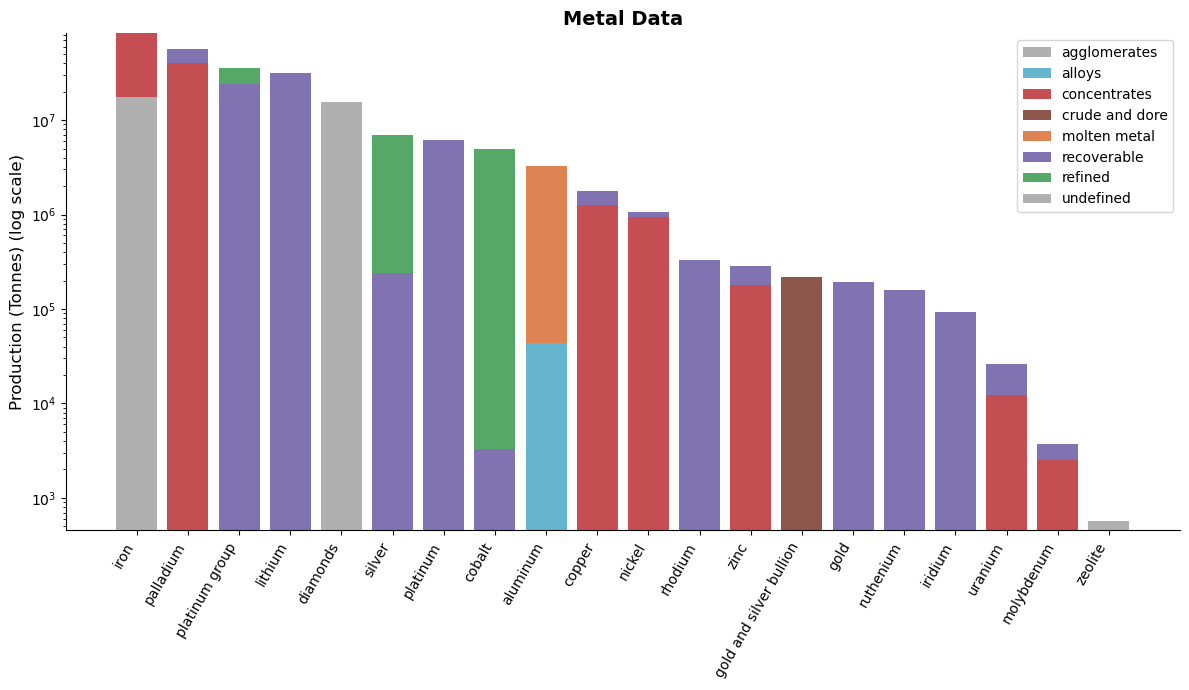

In [27]:
plot_stacked_metal_data(df_nrcan_prod_2023, title="Metal Data", save_prefix='results/technical_validation/nrcan_metal_data_2023')

# Data from USGS MCS

In [28]:
df_usgs = pd.read_csv('data/USGS/Mineral_commodity_summary_2025/MCS2025_World_Data.csv')

In [29]:
df_usgs_can = df_usgs[df_usgs['COUNTRY'].str.contains('Canada', case=False, na=False)]
df_usgs_can

,SOURCE,COMMODITY,COUNTRY,TYPE,UNIT_MEAS,PROD_2023,PROD_EST_ 2024,PROD_NOTES,CAP_2023,CAP_EST_ 2024,CAP_NOTES,RESERVES_2024,RESERVE_NOTES
1,MCS2025,Abrasives,United States and Canada,"Plant capacity, fused aluminum oxide",metric tons,NaN,NaN,,60000.0,60000.0,NaN,NaN,NaN
16,MCS2025,Abrasives,United States and Canada,"Plant capacity, silicon carbide",metric tons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,MCS2025,Aluminum,Canada,"Smelter production, aluminum",thousand metric tons,3200.0,3300.0,estimated 2023,3270.0,3270.0,NaN,NaN,NaN
48,MCS2025,Antimony,Canada,"Mine production, antimony content",metric tons,NaN,NaN,NaN,NaN,NaN,NaN,78000,NaN
92,MCS2025,Bauxite,Canada,"Refinery production, alumina - calcined equiva...",thousand metric dry tons,1500.0,1500.0,NaN,NaN,NaN,NaN,NaN,NaN
113,MCS2025,Bauxite,Canada,"Mine production, bauxite, dry tons",thousand metric dry tons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
169,MCS2025,Cadmium,Canada,"Refinery production, estimated",metric tons,1800.0,1700.0,NaN,NaN,NaN,NaN,NaN,NaN
265,MCS2025,Cobalt,Canada,"Mine production, cobalt content, estimated",metric tons,4220.0,4500.0,NaN,NaN,NaN,NaN,220000,NaN
279,MCS2025,Copper,Canada,"Mine production, recoverable copper content",thousand metric tons,500.0,450.0,NaN,NaN,NaN,NaN,8300,NaN
298,MCS2025,Copper,Canada,"Refinery production, copper",thousand metric tons,315.0,320.0,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
com_to_remove = ['Abrasives', 'Gypsum', 'Helium', 'Lime', 'Magnesium Compounds', 'Mica (Natural)', 'Nitrogen(fixed) - Ammonia', 'Peat ', 'Potash  ', 'Salt ', 'Sand and gravel (industrial)', 'Sulfur', 'Talc, crude', 'Wollastonite', 'Zeolite']

In [31]:
# Remove commodities that are not relevant for the analysis 
df_usgs_can = df_usgs_can[~df_usgs_can['COMMODITY'].isin(com_to_remove)]

In [32]:
# Only keep columns of interest
df_usgs_can = df_usgs_can[['COMMODITY', 'TYPE', 'UNIT_MEAS', 'PROD_2023']]

In [33]:
# Remove NaN value in PROD_2023
df_usgs_can = df_usgs_can[df_usgs_can['PROD_2023'].notna()]

In [34]:
# Rename columns to match NRCan
df_usgs_can.rename(columns={
    'COMMODITY': 'Commodity',
    'TYPE': 'Product_type',
    'UNIT_MEAS': 'Unit',
    'PROD_2023': 'Value'
}, inplace=True)

In [35]:
df_usgs_can['data_source'] = 'USGS MCS 2025'

In [36]:
unit_conversion = {
    "metric tons": 1,
    "thousand metric tons": 1000,
    "thousand metric dry tons": 1000,
    "million metric tons": 1_000_000,  
    "kilograms": 1/1000,
    "thousand carats": 2e-4,  # 1 carat = 0.2 grams, so 1000 carats = 200 grams = 0.0002 tonnes
}

df_usgs_can["conversion_factor"] = df_usgs_can["Unit"].map(unit_conversion)

# Convert value to tonnes
df_usgs_can["Value_tonnes"] = df_usgs_can["Value"] * df_usgs_can["conversion_factor"]
df_usgs_can.drop(columns=["conversion_factor"], inplace=True)
df_usgs_can

,Commodity,Product_type,Unit,Value,data_source,Value_tonnes
34,Aluminum,"Smelter production, aluminum",thousand metric tons,3200.0,USGS MCS 2025,3200000.00
92,Bauxite,"Refinery production, alumina - calcined equiva...",thousand metric dry tons,1500.0,USGS MCS 2025,1500000.00
169,Cadmium,"Refinery production, estimated",metric tons,1800.0,USGS MCS 2025,1800.00
265,Cobalt,"Mine production, cobalt content, estimated",metric tons,4220.0,USGS MCS 2025,4220.00
279,Copper,"Mine production, recoverable copper content",thousand metric tons,500.0,USGS MCS 2025,500000.00
298,Copper,"Refinery production, copper",thousand metric tons,315.0,USGS MCS 2025,315000.00
386,Gemstones,"Mine production, thousand carats of gem-qualit...",thousand carats,16000.0,USGS MCS 2025,3.20
411,Gold,"mine production, gold content",metric tons,198.0,USGS MCS 2025,198.00
429,Graphite,Mine production,metric tons,5470.0,USGS MCS 2025,5470.00
480,Indium,Refinery production,metric tons,40.0,USGS MCS 2025,40.00


In [37]:
# Remove capital letters from Commodity and Product_type
df_usgs_can['Commodity'] = df_usgs_can['Commodity'].str.strip().str.lower()
df_usgs_can

,Commodity,Product_type,Unit,Value,data_source,Value_tonnes
34,aluminum,"Smelter production, aluminum",thousand metric tons,3200.0,USGS MCS 2025,3200000.00
92,bauxite,"Refinery production, alumina - calcined equiva...",thousand metric dry tons,1500.0,USGS MCS 2025,1500000.00
169,cadmium,"Refinery production, estimated",metric tons,1800.0,USGS MCS 2025,1800.00
265,cobalt,"Mine production, cobalt content, estimated",metric tons,4220.0,USGS MCS 2025,4220.00
279,copper,"Mine production, recoverable copper content",thousand metric tons,500.0,USGS MCS 2025,500000.00
298,copper,"Refinery production, copper",thousand metric tons,315.0,USGS MCS 2025,315000.00
386,gemstones,"Mine production, thousand carats of gem-qualit...",thousand carats,16000.0,USGS MCS 2025,3.20
411,gold,"mine production, gold content",metric tons,198.0,USGS MCS 2025,198.00
429,graphite,Mine production,metric tons,5470.0,USGS MCS 2025,5470.00
480,indium,Refinery production,metric tons,40.0,USGS MCS 2025,40.00


# Create validation dataset with NRCan and USGS data

In [38]:
# Concatenate NRCan and USGS data in a single DataFrame
df_validation = pd.concat([df_nrcan_prod_2023, df_usgs_can], ignore_index=True)

In [39]:
# Order alphabetically by Commodity and Product_type
df_validation = df_validation.sort_values(by=['Commodity']).reset_index(drop=True)

In [40]:
df_validation

,Geography,Commodity,Product_type,Variable,Unit,Value,data_source,Value_tonnes
0,canada,aluminum,alloys,quantity produced,Tonnes,43691.0,16100019,4.369100e+04
1,canada,aluminum,molten metal,quantity produced,Tonnes,3258153.0,16100019,3.258153e+06
2,NaN,aluminum,"Smelter production, aluminum",NaN,thousand metric tons,3200.0,USGS MCS 2025,3.200000e+06
3,NaN,bauxite,"Refinery production, alumina - calcined equiva...",NaN,thousand metric dry tons,1500.0,USGS MCS 2025,1.500000e+06
4,NaN,cadmium,"Refinery production, estimated",NaN,metric tons,1800.0,USGS MCS 2025,1.800000e+03
5,canada,cobalt,refined,quantity produced,Kilograms,4923174.0,16100019,4.923174e+03
6,canada,cobalt,recoverable,quantity produced,Tonnes,3260.0,16100022,3.260000e+03
7,NaN,cobalt,"Mine production, cobalt content, estimated",NaN,metric tons,4220.0,USGS MCS 2025,4.220000e+03
8,canada,copper,concentrates,quantity produced,Tonnes,1272135.0,16100022,1.272135e+06
9,canada,copper,recoverable,quantity produced,Tonnes,484552.0,16100022,4.845520e+05


In [41]:
df_validation.to_excel(r'results/technical_validation/df_validation_nrcan_usgs.xlsx', index=False)

# Data from Jasansky et al (2023)

In [3]:
jasansky_min = pd.read_csv('data/Sources/Jasansky_2023/canada_minerals.csv')
jasansky_cap = pd.read_csv('data/Sources/Jasansky_2023/canada_capacity.csv')
jasansky_com = pd.read_csv('data/Sources/Jasansky_2023/canada_commodities.csv')

In [4]:
jasansky_min

,facility_name,facility_type,primary_commodity,commodities_products,id,facility_id,year,type,material,value_tonnes,overall_grade_ppm,amount_sold_tonnes,mine_processing,reporting_period,source_id,comment,sources,source_urls
0,777,Mine,Copper,"Copper, Zinc, Gold, Silver",1,COM00001.00,2013,Ore mined,O.bulk,1625532,NaN,NaN,NaN,NaN,det_1729,NaN,Hudbay Minerals Inc. (2015) Management's Discu...,https://s23.q4cdn.com/405985100/files/doc_fina...
1,777,Mine,Copper,"Copper, Zinc, Gold, Silver",2,COM00001.00,2013,Ore processed,O.bulk,1625532,NaN,NaN,NaN,NaN,det_1729,NaN,Hudbay Minerals Inc. (2015) Management's Discu...,https://s23.q4cdn.com/405985100/files/doc_fina...
2,777,Mine,Copper,"Copper, Zinc, Gold, Silver",3,COM00001.00,2014,Ore mined,O.bulk,1452933,NaN,NaN,NaN,NaN,det_1729,NaN,Hudbay Minerals Inc. (2015) Management's Discu...,https://s23.q4cdn.com/405985100/files/doc_fina...
3,777,Mine,Copper,"Copper, Zinc, Gold, Silver",4,COM00001.00,2014,Ore processed,O.bulk,1452933,NaN,NaN,NaN,NaN,det_1729,NaN,Hudbay Minerals Inc. (2015) Management's Discu...,https://s23.q4cdn.com/405985100/files/doc_fina...
4,777,Mine,Copper,"Copper, Zinc, Gold, Silver",5,COM00001.00,2015,Ore mined,O.bulk,1235053,NaN,NaN,NaN,NaN,det_1730,NaN,Hudbay Minerals Inc. (2016) Management's Discu...,https://s23.q4cdn.com/405985100/files/doc_fina...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,Wabush,Mine,Iron,"Iron, Iron ore pellets",11632,COM01345.00,2006,Concentrate,Con.Fe,4165793,NaN,NaN,NaN,NaN,det_1926,NaN,Cleveland-Cliffs Inc. (2007) 10-K Annual Repor...,http://d1lge852tjjqow.cloudfront.net/CIK-00007...
933,Wabush,Mine,Iron,"Iron, Iron ore pellets",11633,COM01345.00,2007,Concentrate,Con.Fe,4673816,NaN,NaN,NaN,NaN,det_1236,NaN,Cleveland-Cliffs Inc. (2009) 10-K Annual Repor...,http://d1lge852tjjqow.cloudfront.net/CIK-00007...
934,Wabush,Mine,Iron,"Iron, Iron ore pellets",11634,COM01345.00,2008,Concentrate,Con.Fe,4267397,NaN,NaN,NaN,NaN,det_1236,NaN,Cleveland-Cliffs Inc. (2009) 10-K Annual Repor...,http://d1lge852tjjqow.cloudfront.net/CIK-00007...
935,Wabush,Mine,Iron,"Iron, Iron ore pellets",11635,COM01345.00,2013,Concentrate,Con.Fe,2844932,NaN,NaN,NaN,NaN,det_1237,NaN,Cleveland-Cliffs Inc. (2014) 10-K Annual Repor...,http://d1lge852tjjqow.cloudfront.net/CIK-00007...


In [14]:
# Create dfs with the unique facility name
jasansky_min_unique = jasansky_min[['facility_name']].drop_duplicates().reset_index(drop=True)
jasansky_cap_unique = jasansky_cap[['facility_name']].drop_duplicates().reset_index(drop=True)
jasansky_com_unique = jasansky_com[['facility_name']].drop_duplicates().reset_index(drop=True)

In [15]:
# Export the unique facility names to an excel file with different sheets
with pd.ExcelWriter(r'results/technical_validation/jasansky_unique_facilities.xlsx') as writer:
    jasansky_min_unique.to_excel(writer, sheet_name='Mineral Facilities', index=False)
    jasansky_cap_unique.to_excel(writer, sheet_name='Capacity Facilities', index=False)
    jasansky_com_unique.to_excel(writer, sheet_name='Commodity Facilities', index=False)

# Production data from MetalliCan

In [42]:
df_metallican_prod = pd.read_excel(r'data/Tables/extracted_data.xlsx', sheet_name='Production') # Filter for the year 2023

In [43]:
df_metallican_prod

,year,level,geography,reported_company_nrcan,name,main_id,facility_group_id,company_id,facility_type,mining_processing_type,commodities_nrcan,commodity,reference_point,material_type,data_type,method,unit,value,comment,source
0,2023,Site-specific,Canada,Agnico Eagle Mines Limited,Canadian Malartic,QC-MAIN-e7e6a960,NaN,CMP-6265c407,mining,"Underground, concentrator","Gold, silver",Ore,Crude ore,Ore processed,Production,Reported,t,1.959493e+07,NaN,2023-Sustainability-Performance_data
1,2023,Site-specific,Canada,Agnico Eagle Mines Limited,Canadian Malartic,QC-MAIN-e7e6a960,NaN,CMP-6265c407,mining,"Underground, concentrator","Gold, silver",Gold,Usable ore,Contained metal in concentrate,Production,Reported,oz,6.846400e+05,"""Production reflects Agnico Eagle's 50% intere...",2023-Sustainability-Performance_data
2,2023,Site-specific,Canada,Agnico Eagle Mines Limited,Canadian Malartic,QC-MAIN-e7e6a960,NaN,CMP-6265c407,mining,"Underground, concentrator","Gold, silver",Silver,Usable ore,Contained metal in concentrate,Production,Reported,koz,3.100000e+02,"""Production reflects Agnico Eagle's 50% intere...",2023-Sustainability-Performance_data
3,2023,Site-specific,Canada,Agnico Eagle Mines Limited,Detour Lake,ON-MAIN-aeafbb59,NaN,CMP-6265c407,mining,"Open-pit, concentrator",Gold,Gold,Crude ore,Ore processed,Production,Reported,t,2.543485e+07,NaN,2023-Sustainability-Performance_data
4,2023,Site-specific,Canada,Agnico Eagle Mines Limited,Detour Lake,ON-MAIN-aeafbb59,NaN,CMP-6265c407,mining,"Open-pit, concentrator",Gold,Gold,Usable ore,Contained metal in concentrate,Production,Reported,oz,6.774460e+05,NaN,2023-Sustainability-Performance_data
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,2023,Site-specific,Canada,Vale,Voisey’s Bay,NL-MAIN-d9036091,NaN,CMP-9617aef4,mining,"Open-pit, underground, concentrator","Nickel, copper, cobalt",Nickel,Usable ore,Contained metal in concentrate,Production,Reported,kt,1.350000e+01,"""Finished production"", unclear what it refers to",Vale's performance in 1Q25 - xls
215,2023,Site-specific,Canada,Wesdome Gold Mines Ltd,Eagle River,QC-MAIN-9de9bb0d,NaN,CMP-3d2c4955,mining,"Underground, concentrator",Gold,Gold,Usable ore,Contained metal in concentrate,Production,Reported,Oz,8.746700e+04,Gold production',2024-MDA-FINAL
216,2023,Site-specific,Canada,Wesdome Gold Mines Ltd,Eagle River,QC-MAIN-9de9bb0d,NaN,CMP-3d2c4955,mining,"Underground, concentrator",Gold,Gold,Crude ore,Ore milled,Production,Reported,t,2.226270e+05,NaN,2024-MDA-FINAL
217,2023,Site-specific,Canada,Wesdome Gold Mines Ltd,Kiena,ON-MAIN-c5fefb01,NaN,CMP-3d2c4955,mining,"Open-pit, concentrator",Gold,Gold,Usable ore,Contained metal in concentrate,Production,Reported,Oz,3.553700e+04,Gold production',2024-MDA-FINAL


In [44]:
df_metallican_prod = df_metallican_prod[
    (df_metallican_prod["data_type"] == "Production") &
    (df_metallican_prod["geography"] == "Canada")
].copy()

In [45]:
# Temporarily replace year 2022 and 2024 with 2023 for consistency
df_metallican_prod["year"] = df_metallican_prod["year"].replace({2021: 2023, 2022: 2023, 2024: 2023})

In [46]:
df_metallican_prod["unit_normalized"] = df_metallican_prod["unit"].str.strip().str.lower()

In [47]:
from constants import unit_conversion

In [48]:
df_metallican_prod["conversion_factor"] = df_metallican_prod["unit_normalized"].map(unit_conversion)
df_metallican_prod["value_tonnes"] = df_metallican_prod["value"] * df_metallican_prod["conversion_factor"]
df_metallican_prod

,year,level,geography,reported_company_nrcan,name,main_id,facility_group_id,company_id,facility_type,mining_processing_type,...,material_type,data_type,method,unit,value,comment,source,unit_normalized,conversion_factor,value_tonnes
0,2023,Site-specific,Canada,Agnico Eagle Mines Limited,Canadian Malartic,QC-MAIN-e7e6a960,NaN,CMP-6265c407,mining,"Underground, concentrator",...,Ore processed,Production,Reported,t,1.959493e+07,NaN,2023-Sustainability-Performance_data,t,1.000000,1.959493e+07
1,2023,Site-specific,Canada,Agnico Eagle Mines Limited,Canadian Malartic,QC-MAIN-e7e6a960,NaN,CMP-6265c407,mining,"Underground, concentrator",...,Contained metal in concentrate,Production,Reported,oz,6.846400e+05,"""Production reflects Agnico Eagle's 50% intere...",2023-Sustainability-Performance_data,oz,0.000031,2.129470e+01
2,2023,Site-specific,Canada,Agnico Eagle Mines Limited,Canadian Malartic,QC-MAIN-e7e6a960,NaN,CMP-6265c407,mining,"Underground, concentrator",...,Contained metal in concentrate,Production,Reported,koz,3.100000e+02,"""Production reflects Agnico Eagle's 50% intere...",2023-Sustainability-Performance_data,koz,0.031103,9.642085e+00
3,2023,Site-specific,Canada,Agnico Eagle Mines Limited,Detour Lake,ON-MAIN-aeafbb59,NaN,CMP-6265c407,mining,"Open-pit, concentrator",...,Ore processed,Production,Reported,t,2.543485e+07,NaN,2023-Sustainability-Performance_data,t,1.000000,2.543485e+07
4,2023,Site-specific,Canada,Agnico Eagle Mines Limited,Detour Lake,ON-MAIN-aeafbb59,NaN,CMP-6265c407,mining,"Open-pit, concentrator",...,Contained metal in concentrate,Production,Reported,oz,6.774460e+05,NaN,2023-Sustainability-Performance_data,oz,0.000031,2.107094e+01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,2023,Site-specific,Canada,Vale,Voisey’s Bay,NL-MAIN-d9036091,NaN,CMP-9617aef4,mining,"Open-pit, underground, concentrator",...,Contained metal in concentrate,Production,Reported,kt,1.350000e+01,"""Finished production"", unclear what it refers to",Vale's performance in 1Q25 - xls,kt,1000.000000,1.350000e+04
215,2023,Site-specific,Canada,Wesdome Gold Mines Ltd,Eagle River,QC-MAIN-9de9bb0d,NaN,CMP-3d2c4955,mining,"Underground, concentrator",...,Contained metal in concentrate,Production,Reported,Oz,8.746700e+04,Gold production',2024-MDA-FINAL,oz,0.000031,2.720530e+00
216,2023,Site-specific,Canada,Wesdome Gold Mines Ltd,Eagle River,QC-MAIN-9de9bb0d,NaN,CMP-3d2c4955,mining,"Underground, concentrator",...,Ore milled,Production,Reported,t,2.226270e+05,NaN,2024-MDA-FINAL,t,1.000000,2.226270e+05
217,2023,Site-specific,Canada,Wesdome Gold Mines Ltd,Kiena,ON-MAIN-c5fefb01,NaN,CMP-3d2c4955,mining,"Open-pit, concentrator",...,Contained metal in concentrate,Production,Reported,Oz,3.553700e+04,Gold production',2024-MDA-FINAL,oz,0.000031,1.105325e+00


In [49]:
missing_units = df_metallican_prod[df_metallican_prod["conversion_factor"].isna()]["unit_normalized"].unique()
print("⚠️ Units not mapped:", missing_units)

⚠️ Units not mapped: []


In [50]:
summary_metallican_2023 = df_metallican_prod.groupby(["commodity", "reference_point", "material_type"])["value_tonnes"].sum().reset_index()
summary_metallican_2023

,commodity,reference_point,material_type,value_tonnes
0,Alumina,Intermediate metal produced,Smelter grade alumina,1.391806e+06
1,Aluminum,Intermediate metal produced,Smelter production,2.140163e+06
2,Cobalt,Refined metal produced,Refinery production,3.368000e+03
3,Concentrate,Usable ore,Concentrate,1.422850e+05
4,Copper,Usable ore,Concentrate,2.165873e+05
5,Copper,Usable ore,Contained metal in concentrate,2.782811e+05
6,Copper,Usable ore,Contained metal in concentrate and doré produced,1.215400e+04
7,Diamonds,Crude ore,Ore processed,4.200000e+06
8,Diamonds,Total extraction,Ore mined,4.600000e+06
9,Diamonds,Usable ore,Carats recovered,1.020000e+00


In [51]:
summary_metallican_2023.to_excel(r'results/technical_validation/summary_metallican_2023_updated.xlsx', index=False)

# Compare NRCan and MetalliCan data

In [52]:
summary_metallican_2023

,commodity,reference_point,material_type,value_tonnes
0,Alumina,Intermediate metal produced,Smelter grade alumina,1.391806e+06
1,Aluminum,Intermediate metal produced,Smelter production,2.140163e+06
2,Cobalt,Refined metal produced,Refinery production,3.368000e+03
3,Concentrate,Usable ore,Concentrate,1.422850e+05
4,Copper,Usable ore,Concentrate,2.165873e+05
5,Copper,Usable ore,Contained metal in concentrate,2.782811e+05
6,Copper,Usable ore,Contained metal in concentrate and doré produced,1.215400e+04
7,Diamonds,Crude ore,Ore processed,4.200000e+06
8,Diamonds,Total extraction,Ore mined,4.600000e+06
9,Diamonds,Usable ore,Carats recovered,1.020000e+00


In [53]:
df_validation = pd.read_excel(r'results/technical_validation/df_validation_nrcan_usgs.xlsx')

In [54]:
# Define mapping from product_type to reference_point_label
product_type_to_reference_point = {
    # Steel industry
    "Raw steel": "Refined metal produced",
    "Pig iron": "Intermediate metal produced",
    
    # Refined and intermediate metals
    "molten metal": "Intermediate metal produced",
    "alloys": "Intermediate metal produced",  # or refined?
    "Smelter production, aluminum": "Intermediate metal produced",
    "Refinery production, alumina - calcined equivalent weights": "Refined metal produced",
    "Refinery production, estimated": "Refined metal produced",
    "refined": "Refined metal produced",
    "Refinery production, copper": "Refined metal produced",
    "Refinery production": "Refined metal produced",
    "crude and dore": "Intermediate metal produced", # or refined?
    "Refinery production, selenium content": "Refined metal produced",
    "Refinery production, tellurium content": "Refined metal produced",
    "Plant production, silicon metal": "Refined metal produced",
    "Plant production, Ferosilicon, silicon content ": "Refined metal produced",

    # Usable ore
    "concentrates": "Usable ore", 
    "agglomerates": "Usable ore",
    "recoverable": "Usable ore",
    "Mine production, recoverable copper content": "Usable ore",
    "Mine production, cobalt content, estimated": "Usable ore",
    "Mine production, usable ore": "Usable ore",
    "Mine production, iron content": "Usable ore",
    "Mine production, lithium content": "Usable ore",
    "Mine production, magnesite - gross weight": "Usable ore",
    "Mine production, molybdenum content": "Usable ore",
    "Mine production, nickel content": "Usable ore",
    "Mine production, niobium content": "Usable ore",
    "Mine production, gold content": "Usable ore",
    "mine production, gold content": "Usable ore",
    "Mine production, Palladium content": "Usable ore",
    "Mine production, Platinum content": "Usable ore",
    "Mine production, silver content": "Usable ore",
    "Mine production, ilmentite, titanium dioxide (TiO2) content": "Usable ore",
    "Mine production, thousand carats of gem-quality diamond": "Usable ore",

    # Crude ore
    "Mine production": "Crude ore",

    # Unclear
    "undefined": None,
}

In [55]:
# Apply the mapping
df_validation["reference_point"] = df_validation["Product_type"].map(product_type_to_reference_point)

In [56]:
# Standardize casing in both datasets
df_db = summary_metallican_2023.copy()
df_db["source"] = "MetalliCan"
df_db.rename(columns={"material_type": "Product_type"}, inplace=True)
df_db["commodity"] = df_db["commodity"].str.strip().str.lower()
df_db["reference_point"] = df_db["reference_point"].str.strip().str.lower()

df_for_validation = df_validation[["Commodity", "reference_point", "Product_type", "Value_tonnes", "data_source"]].copy()
df_for_validation.rename(columns={"Commodity": "commodity",
                                  "Value_tonnes": "value_tonnes",
                                  "data_source": "source"}, inplace=True)
df_for_validation["commodity"] = df_for_validation["commodity"].str.strip().str.lower()
df_for_validation["reference_point"] = df_for_validation["reference_point"].str.strip().str.lower()

# Concatenate both for comparison
df_comparison = pd.concat([df_db, df_for_validation], ignore_index=True)

# Pivot the data to make source columns side-by-side
df_comparison_pivot = df_comparison.pivot_table(
    index=["commodity", "reference_point"],
    columns="source",
    values="value_tonnes",
    aggfunc="sum"
).reset_index()

df_comparison

,commodity,reference_point,Product_type,value_tonnes,source
0,alumina,intermediate metal produced,Smelter grade alumina,1.391806e+06,MetalliCan
1,aluminum,intermediate metal produced,Smelter production,2.140163e+06,MetalliCan
2,cobalt,refined metal produced,Refinery production,3.368000e+03,MetalliCan
3,concentrate,usable ore,Concentrate,1.422850e+05,MetalliCan
4,copper,usable ore,Concentrate,2.165873e+05,MetalliCan
...,...,...,...,...,...
110,uranium,usable ore,concentrates,1.236600e+04,16100022
111,uranium,usable ore,recoverable,1.388400e+04,16100022
112,zeolite,None,undefined,5.650000e+02,16100022
113,zinc,usable ore,concentrates,1.774390e+05,16100022


In [57]:
# Sort alphabetically by commodity
df_comparison = df_comparison.sort_values(by='commodity').reset_index(drop=True)

In [58]:
# Ensure that value_tonnes is numeric
df_comparison["value_tonnes"] = pd.to_numeric(df_comparison["value_tonnes"], errors='coerce')

In [59]:
# In the source column, eplace 16100022 with 'NRCan 2023' and 16100019 with 'NRCan Monthly 2023'
df_comparison['source'] = df_comparison['source'].replace({
    '16100022': 'NRCan 2023 yearly',
    '16100019': 'NRCan 2023 monthly'
})

In [60]:
df_comparison

,commodity,reference_point,Product_type,value_tonnes,source
0,alumina,intermediate metal produced,Smelter grade alumina,1.391806e+06,MetalliCan
1,aluminum,intermediate metal produced,"Smelter production, aluminum",3.200000e+06,USGS MCS 2025
2,aluminum,intermediate metal produced,alloys,4.369100e+04,NRCan 2023 monthly
3,aluminum,intermediate metal produced,molten metal,3.258153e+06,NRCan 2023 monthly
4,aluminum,intermediate metal produced,Smelter production,2.140163e+06,MetalliCan
...,...,...,...,...,...
110,zinc,usable ore,Contained metal in concentrate,7.458100e+04,MetalliCan
111,zinc,usable ore,Concentrate,1.080410e+05,MetalliCan
112,zinc,refined metal produced,Refinery production,1.008600e+06,MetalliCan
113,zinc,usable ore,concentrates,1.774390e+05,NRCan 2023 yearly


In [61]:
df_comparison.to_excel(r'results/technical_validation/df_comparison_metallican_nrcan_updated.xlsx', index=False)